
## PROJECT  : Customer Credit Scoring Model
### Author   : Moreen Gatwiri
### Tool     : Python (Pandas, NumPy, Matplotlib, Seaborn)
### Domain   : Credit Risk & Banking Analytics


#### SECTION 1 — IMPORTING LIBRARIES

In [2]:
# --- Import Libraries ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')

In [3]:
# --- Plot Styling ---
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.facecolor'] = '#0A3D3A'
plt.rcParams['figure.facecolor'] = '#080F14'
plt.rcParams['axes.labelcolor'] = 'white'
plt.rcParams['xtick.color'] = 'white'
plt.rcParams['ytick.color'] = 'white'
plt.rcParams['text.color'] = 'white'
plt.rcParams['axes.titlecolor'] = 'white'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

In [4]:
# --- Create Output Folders ---
os.makedirs('data', exist_ok=True)
os.makedirs('outputs', exist_ok=True)
os.makedirs('outputs/charts', exist_ok=True)

print("✅ Libraries imported successfully")
print("✅ Output folders created")
print("✅ Ready to begin analysis")

✅ Libraries imported successfully
✅ Output folders created
✅ Ready to begin analysis


#### SECTION 2 — DATA GENERATION


In [5]:
# Simulating 1,000 customer loan applications

np.random.seed(42)  # ensures same data every time we run
n = 1000

# --- Customer Demographics ---
cities = ['Nairobi', 'Mombasa', 'Kisumu', 'Nakuru', 'Eldoret',
          'Thika', 'Nyeri', 'Kitale', 'Karen', 'Westlands']

employment_types = ['Employed', 'Self-Employed', 'Business Owner']
loan_types = ['Mortgage', 'SME', 'Personal', 'Asset Finance']
genders = ['Male', 'Female']

customer_ids   = [f'CUST{str(i).zfill(4)}' for i in range(1, n+1)]
customer_names = [f'Customer_{i}' for i in range(1, n+1)]
ages           = np.random.randint(22, 65, n)
gender_col     = np.random.choice(genders, n)
city_col       = np.random.choice(cities, n)
employment     = np.random.choice(employment_types, n, p=[0.5, 0.3, 0.2])
years_employed = np.random.randint(1, 25, n)

# --- Financial Profile ---
monthly_income = np.random.randint(30000, 500000, n)
existing_debt  = (monthly_income * np.random.uniform(0.1, 0.6, n)).astype(int)

loan_type_col  = np.random.choice(loan_types, n, p=[0.4, 0.25, 0.25, 0.10])

# Loan amounts based on loan type
loan_amounts = np.where(loan_type_col == 'Mortgage',
                   np.random.randint(3000000, 20000000, n),
               np.where(loan_type_col == 'SME',
                   np.random.randint(500000, 8000000, n),
               np.where(loan_type_col == 'Personal',
                   np.random.randint(50000, 1000000, n),
                   np.random.randint(500000, 5000000, n))))

loan_tenure    = np.random.choice([12, 24, 36, 48, 60, 84, 120, 240], n)
interest_rates = np.round(np.random.uniform(10.5, 25.0, n), 2)
collateral     = (loan_amounts * np.random.uniform(0.5, 1.8, n)).astype(int)

# --- Credit Behaviour ---
payment_history = np.random.randint(40, 100, n)
previous_defaults = np.random.choice([0, 1, 2, 3], n, p=[0.65, 0.20, 0.10, 0.05])

# --- Build DataFrame ---
df = pd.DataFrame({
    'customer_id':          customer_ids,
    'customer_name':        customer_names,
    'age':                  ages,
    'gender':               gender_col,
    'city':                 city_col,
    'employment_type':      employment,
    'years_employed':       years_employed,
    'monthly_income':       monthly_income,
    'existing_debt':        existing_debt,
    'loan_type':            loan_type_col,
    'loan_amount':          loan_amounts,
    'loan_tenure_months':   loan_tenure,
    'interest_rate':        interest_rates,
    'collateral_value':     collateral,
    'payment_history_score':payment_history,
    'previous_defaults':    previous_defaults,
})

# --- Save to CSV ---
df.to_csv('data/loan_applications.csv', index=False)

print(f"✅ Dataset generated: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"✅ Saved to data/loan_applications.csv")
print(f"\n📊 Loan Type Distribution:")
print(df['loan_type'].value_counts())

✅ Dataset generated: 1000 rows x 16 columns
✅ Saved to data/loan_applications.csv

📊 Loan Type Distribution:
loan_type
Mortgage         418
SME              240
Personal         240
Asset Finance    102
Name: count, dtype: int64


#### SECTION 3 — DATA OVERVIEW & CLEANING

In [6]:
print("=" * 55)
print("  CUSTOMER CREDIT SCORING MODEL — DATA OVERVIEW")
print("=" * 55)

# --- Basic Info ---
print(f"\n📋 Dataset Shape   : {df.shape[0]} rows x {df.shape[1]} columns")
print(f"💾 Memory Usage    : {df.memory_usage(deep=True).sum() / 1024:.1f} KB")

# --- Data Types ---
print("\n📌 Column Data Types:")
print(df.dtypes.to_string())

# --- Missing Values ---
print("\n🔍 Missing Values Check:")
missing = df.isnull().sum()
if missing.sum() == 0:
    print("   ✅ No missing values found — dataset is clean!")
else:
    print(missing[missing > 0])

# --- Duplicates ---
dupes = df.duplicated().sum()
print(f"\n🔍 Duplicate Rows  : {dupes}")
if dupes == 0:
    print("   ✅ No duplicates found!")

# --- Statistical Summary ---
print("\n📊 Statistical Summary (Numerical Columns):")
print(df[['age', 'monthly_income', 'existing_debt',
          'loan_amount', 'collateral_value',
          'payment_history_score', 'previous_defaults']].describe().round(0).to_string())

  CUSTOMER CREDIT SCORING MODEL — DATA OVERVIEW

📋 Dataset Shape   : 1000 rows x 16 columns
💾 Memory Usage    : 393.9 KB

📌 Column Data Types:
customer_id               object
customer_name             object
age                        int32
gender                    object
city                      object
employment_type           object
years_employed             int32
monthly_income             int32
existing_debt              int64
loan_type                 object
loan_amount                int32
loan_tenure_months         int64
interest_rate            float64
collateral_value           int64
payment_history_score      int32
previous_defaults          int64

🔍 Missing Values Check:
   ✅ No missing values found — dataset is clean!

🔍 Duplicate Rows  : 0
   ✅ No duplicates found!

📊 Statistical Summary (Numerical Columns):
          age  monthly_income  existing_debt  loan_amount  collateral_value  payment_history_score  previous_defaults
count  1000.0          1000.0         1000.0

#### SECTION 4 — FEATURE ENGINEERING

In [7]:

# Creating calculated risk factors for scoring

# --- 1. Debt-to-Income Ratio (DTI) ---
# How much of monthly income is already committed to debt
# Lower is better — above 0.5 is high risk
df['monthly_repayment'] = (
    df['loan_amount'] * (df['interest_rate'] / 100 / 12) /
    (1 - (1 + df['interest_rate'] / 100 / 12) ** (-df['loan_tenure_months']))
).round(0)

df['total_debt_obligations'] = df['existing_debt'] + df['monthly_repayment']
df['debt_to_income_ratio']   = (df['total_debt_obligations'] / df['monthly_income']).round(3)

# --- 2. Collateral Coverage Ratio (CCR) ---
# How well the loan is secured by collateral
# Above 1.0 means fully covered — below 1.0 means under-collateralised
df['collateral_coverage_ratio'] = (df['collateral_value'] / df['loan_amount']).round(3)

# --- 3. Income-to-Loan Ratio ---
# Annual income vs loan amount — higher is better
df['income_to_loan_ratio'] = (
    (df['monthly_income'] * 12) / df['loan_amount']
).round(3)

# --- 4. Loan-to-Value Ratio (LTV) ---
# Standard banking metric — loan as % of collateral
df['loan_to_value'] = (df['loan_amount'] / df['collateral_value']).round(3)

# --- 5. Employment Stability Score ---
# Converts employment type + years into a stability score
df['employment_stability'] = np.where(
    df['employment_type'] == 'Employed',       df['years_employed'] * 1.2,
    np.where(df['employment_type'] == 'Business Owner', df['years_employed'] * 1.1,
                                                         df['years_employed'] * 0.9)
).round(1)

# --- Summary ---
print("✅ New Features Created:")
print(f"   monthly_repayment         — estimated monthly loan repayment")
print(f"   total_debt_obligations    — existing debt + new repayment")
print(f"   debt_to_income_ratio      — total obligations / monthly income")
print(f"   collateral_coverage_ratio — collateral value / loan amount")
print(f"   income_to_loan_ratio      — annual income / loan amount")
print(f"   loan_to_value             — loan amount / collateral value")
print(f"   employment_stability      — employment type + tenure score")

print(f"\n📊 Key Feature Averages:")
print(f"   Avg DTI Ratio             : {df['debt_to_income_ratio'].mean():.2f}")
print(f"   Avg Collateral Coverage   : {df['collateral_coverage_ratio'].mean():.2f}")
print(f"   Avg Income-to-Loan        : {df['income_to_loan_ratio'].mean():.2f}")
print(f"   Avg Loan-to-Value         : {df['loan_to_value'].mean():.2f}")

print(f"\n⚠️  High DTI Customers (>0.5): {(df['debt_to_income_ratio'] > 0.5).sum()}")
print(f"⚠️  Under-Collateralised (<1.0): {(df['collateral_coverage_ratio'] < 1.0).sum()}")

✅ New Features Created:
   monthly_repayment         — estimated monthly loan repayment
   total_debt_obligations    — existing debt + new repayment
   debt_to_income_ratio      — total obligations / monthly income
   collateral_coverage_ratio — collateral value / loan amount
   income_to_loan_ratio      — annual income / loan amount
   loan_to_value             — loan amount / collateral value
   employment_stability      — employment type + tenure score

📊 Key Feature Averages:
   Avg DTI Ratio             : 1.66
   Avg Collateral Coverage   : 1.15
   Avg Income-to-Loan        : 2.88
   Avg Loan-to-Value         : 0.98

⚠️  High DTI Customers (>0.5): 769
⚠️  Under-Collateralised (<1.0): 383


#### Section 5 — Credit Score Calculation

In [8]:

# Weighted scorecard model (300 - 850 scale)


def calculate_credit_score(row):
    score = 0

    # ── FACTOR 1: Payment History (35% weight) ──────────────
    # Based on payment_history_score (0-100) and previous defaults
    payment_score = row['payment_history_score']

    if row['previous_defaults'] == 0:
        payment_points = (payment_score / 100) * 35
    elif row['previous_defaults'] == 1:
        payment_points = (payment_score / 100) * 35 * 0.7
    elif row['previous_defaults'] == 2:
        payment_points = (payment_score / 100) * 35 * 0.4
    else:
        payment_points = (payment_score / 100) * 35 * 0.1

    score += payment_points

    # ── FACTOR 2: Debt-to-Income Ratio (25% weight) ─────────
    dti = row['debt_to_income_ratio']

    if dti <= 0.3:
        dti_points = 25
    elif dti <= 0.4:
        dti_points = 22
    elif dti <= 0.5:
        dti_points = 18
    elif dti <= 0.6:
        dti_points = 13
    elif dti <= 0.8:
        dti_points = 8
    elif dti <= 1.0:
        dti_points = 4
    else:
        dti_points = 0

    score += dti_points

    # ── FACTOR 3: Collateral Coverage (20% weight) ───────────
    ccr = row['collateral_coverage_ratio']

    if ccr >= 1.5:
        col_points = 20
    elif ccr >= 1.2:
        col_points = 17
    elif ccr >= 1.0:
        col_points = 13
    elif ccr >= 0.8:
        col_points = 8
    elif ccr >= 0.5:
        col_points = 4
    else:
        col_points = 0

    score += col_points

    # ── FACTOR 4: Loan Tenure / Credit History (10% weight) ──
    tenure = row['loan_tenure_months']

    if tenure >= 120:
        tenure_points = 10
    elif tenure >= 60:
        tenure_points = 8
    elif tenure >= 36:
        tenure_points = 6
    elif tenure >= 24:
        tenure_points = 4
    else:
        tenure_points = 2

    score += tenure_points

    # ── FACTOR 5: Income Stability (10% weight) ───────────────
    income_loan = row['income_to_loan_ratio']

    if income_loan >= 1.0:
        income_points = 10
    elif income_loan >= 0.5:
        income_points = 8
    elif income_loan >= 0.3:
        income_points = 5
    elif income_loan >= 0.1:
        income_points = 2
    else:
        income_points = 0

    score += income_points

    # ── Scale from 0-100 to 300-850 ───────────────────────────
    final_score = 300 + (score / 100) * 550

    return round(final_score)


# --- Apply scoring model to all 1,000 customers ---
df['credit_score'] = df.apply(calculate_credit_score, axis=1)

# --- Assign Credit Rating Tier ---
def assign_rating(score):
    if score >= 750:
        return 'Excellent'
    elif score >= 700:
        return 'Good'
    elif score >= 650:
        return 'Fair'
    elif score >= 600:
        return 'Poor'
    else:
        return 'Very Poor'

df['credit_rating'] = df['credit_score'].apply(assign_rating)

# --- Assign Loan Decision ---
def assign_decision(score):
    if score >= 750:
        return 'Auto Approve'
    elif score >= 700:
        return 'Approve'
    elif score >= 650:
        return 'Review Required'
    elif score >= 600:
        return 'Conditional Approval'
    else:
        return 'Decline'

df['loan_decision'] = df['credit_score'].apply(assign_decision)

# --- Results Summary ---
print("✅ Credit scores calculated for all 1,000 customers")
print(f"\n📊 Score Statistics:")
print(f"   Minimum Score  : {df['credit_score'].min()}")
print(f"   Maximum Score  : {df['credit_score'].max()}")
print(f"   Average Score  : {df['credit_score'].mean():.0f}")
print(f"   Median Score   : {df['credit_score'].median():.0f}")

print(f"\n🏷️  Credit Rating Distribution:")
rating_order = ['Excellent', 'Good', 'Fair', 'Poor', 'Very Poor']
rating_counts = df['credit_rating'].value_counts().reindex(rating_order)
for rating, count in rating_counts.items():
    pct = count / len(df) * 100
    print(f"   {rating:<20} : {count:>4} customers ({pct:.1f}%)")

print(f"\n🏦 Loan Decision Distribution:")
decision_order = ['Auto Approve', 'Approve', 'Review Required',
                  'Conditional Approval', 'Decline']
decision_counts = df['loan_decision'].value_counts().reindex(decision_order)
for decision, count in decision_counts.items():
    pct = count / len(df) * 100
    print(f"   {decision:<22} : {count:>4} customers ({pct:.1f}%)")

✅ Credit scores calculated for all 1,000 customers

📊 Score Statistics:
   Minimum Score  : 375
   Maximum Score  : 820
   Average Score  : 597
   Median Score   : 596

🏷️  Credit Rating Distribution:
   Excellent            :   55 customers (5.5%)
   Good                 :   94 customers (9.4%)
   Fair                 :  134 customers (13.4%)
   Poor                 :  198 customers (19.8%)
   Very Poor            :  519 customers (51.9%)

🏦 Loan Decision Distribution:
   Auto Approve           :   55 customers (5.5%)
   Approve                :   94 customers (9.4%)
   Review Required        :  134 customers (13.4%)
   Conditional Approval   :  198 customers (19.8%)
   Decline                :  519 customers (51.9%)


#### Section 6 — Score Distribution Chart

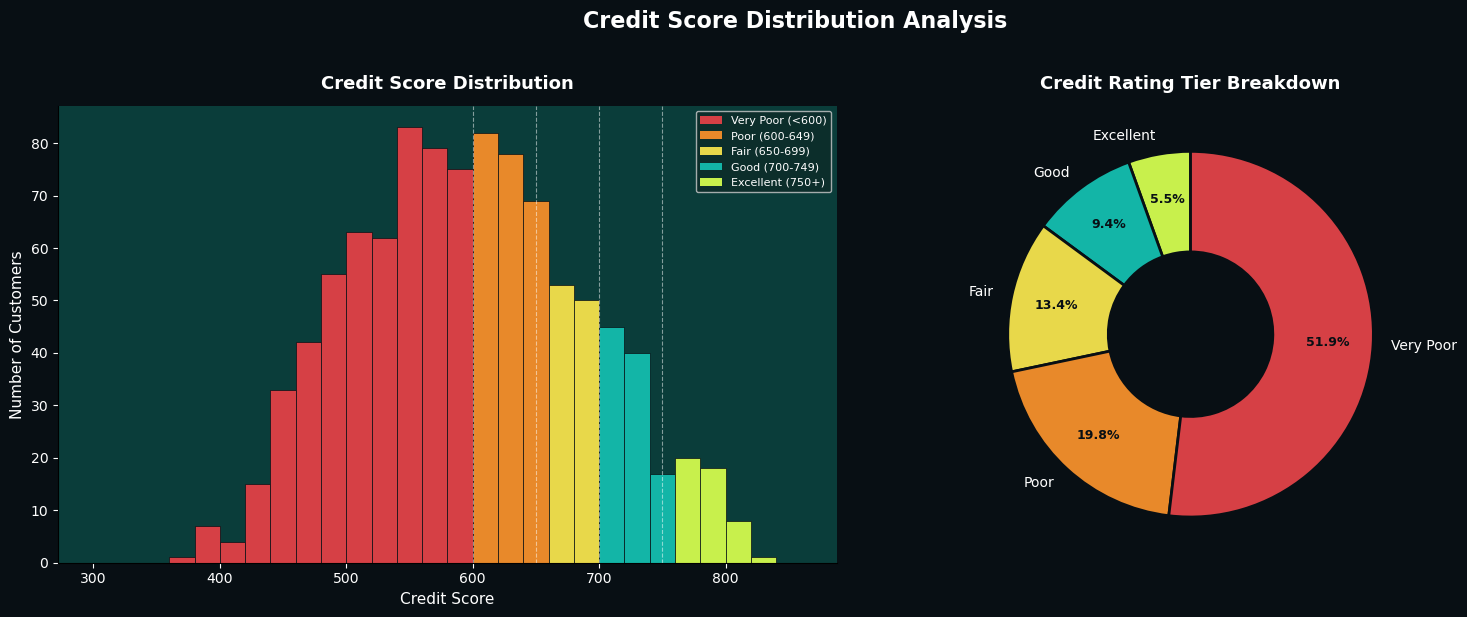

✅ Chart saved to outputs/charts/01_score_distribution.png


In [9]:

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Credit Score Distribution Analysis',
             fontsize=16, fontweight='bold', color='white', y=1.02)

# ── Chart 1: Score Histogram ─────────────────────
ax1 = axes[0]
ax1.set_facecolor('#0A3D3A')

# Score zone colours
zone_colors = {
    'Very Poor':  '#D64045',
    'Poor':       '#E8892A',
    'Fair':       '#E8D84A',
    'Good':       '#13B5A7',
    'Excellent':  '#C8F04C',
}

# Plot histogram with zone colouring
bins = range(300, 870, 20)
n_hist, bin_edges, patches = ax1.hist(
    df['credit_score'], bins=bins, edgecolor='#080F14', linewidth=0.5
)

# Colour each bar by score zone
for patch, left_edge in zip(patches, bin_edges[:-1]):
    if left_edge < 600:
        patch.set_facecolor('#D64045')
    elif left_edge < 650:
        patch.set_facecolor('#E8892A')
    elif left_edge < 700:
        patch.set_facecolor('#E8D84A')
    elif left_edge < 750:
        patch.set_facecolor('#13B5A7')
    else:
        patch.set_facecolor('#C8F04C')

# Zone boundary lines
for boundary, label in [(600, 'Poor'), (650, 'Fair'),
                        (700, 'Good'), (750, 'Excellent')]:
    ax1.axvline(x=boundary, color='white', linestyle='--',
                linewidth=0.8, alpha=0.5)

ax1.set_title('Credit Score Distribution', fontsize=13,
              fontweight='bold', color='white', pad=12)
ax1.set_xlabel('Credit Score', fontsize=11)
ax1.set_ylabel('Number of Customers', fontsize=11)
ax1.tick_params(colors='white')

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#D64045', label='Very Poor (<600)'),
    Patch(facecolor='#E8892A', label='Poor (600-649)'),
    Patch(facecolor='#E8D84A', label='Fair (650-699)'),
    Patch(facecolor='#13B5A7', label='Good (700-749)'),
    Patch(facecolor='#C8F04C', label='Excellent (750+)'),
]
ax1.legend(handles=legend_elements, loc='upper right',
           fontsize=8, facecolor='#0D2B28', labelcolor='white')

# ── Chart 2: Rating Tier Donut ───────────────────
ax2 = axes[1]
ax2.set_facecolor('#080F14')

rating_order  = ['Excellent', 'Good', 'Fair', 'Poor', 'Very Poor']
rating_counts = df['credit_rating'].value_counts().reindex(rating_order)
colors        = ['#C8F04C', '#13B5A7', '#E8D84A', '#E8892A', '#D64045']

wedges, texts, autotexts = ax2.pie(
    rating_counts,
    labels=rating_order,
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.75,
    wedgeprops=dict(width=0.55, edgecolor='#080F14', linewidth=2)
)

for text in texts:
    text.set_color('white')
    text.set_fontsize(10)
for autotext in autotexts:
    autotext.set_color('#080F14')
    autotext.set_fontsize(9)
    autotext.set_fontweight('bold')

ax2.set_title('Credit Rating Tier Breakdown',
              fontsize=13, fontweight='bold', color='white', pad=12)

plt.tight_layout()
plt.savefig('outputs/charts/01_score_distribution.png',
            dpi=150, bbox_inches='tight',
            facecolor='#080F14')
plt.show()
print("✅ Chart saved to outputs/charts/01_score_distribution.png")
 

#### Section 7 — Factor Analysis

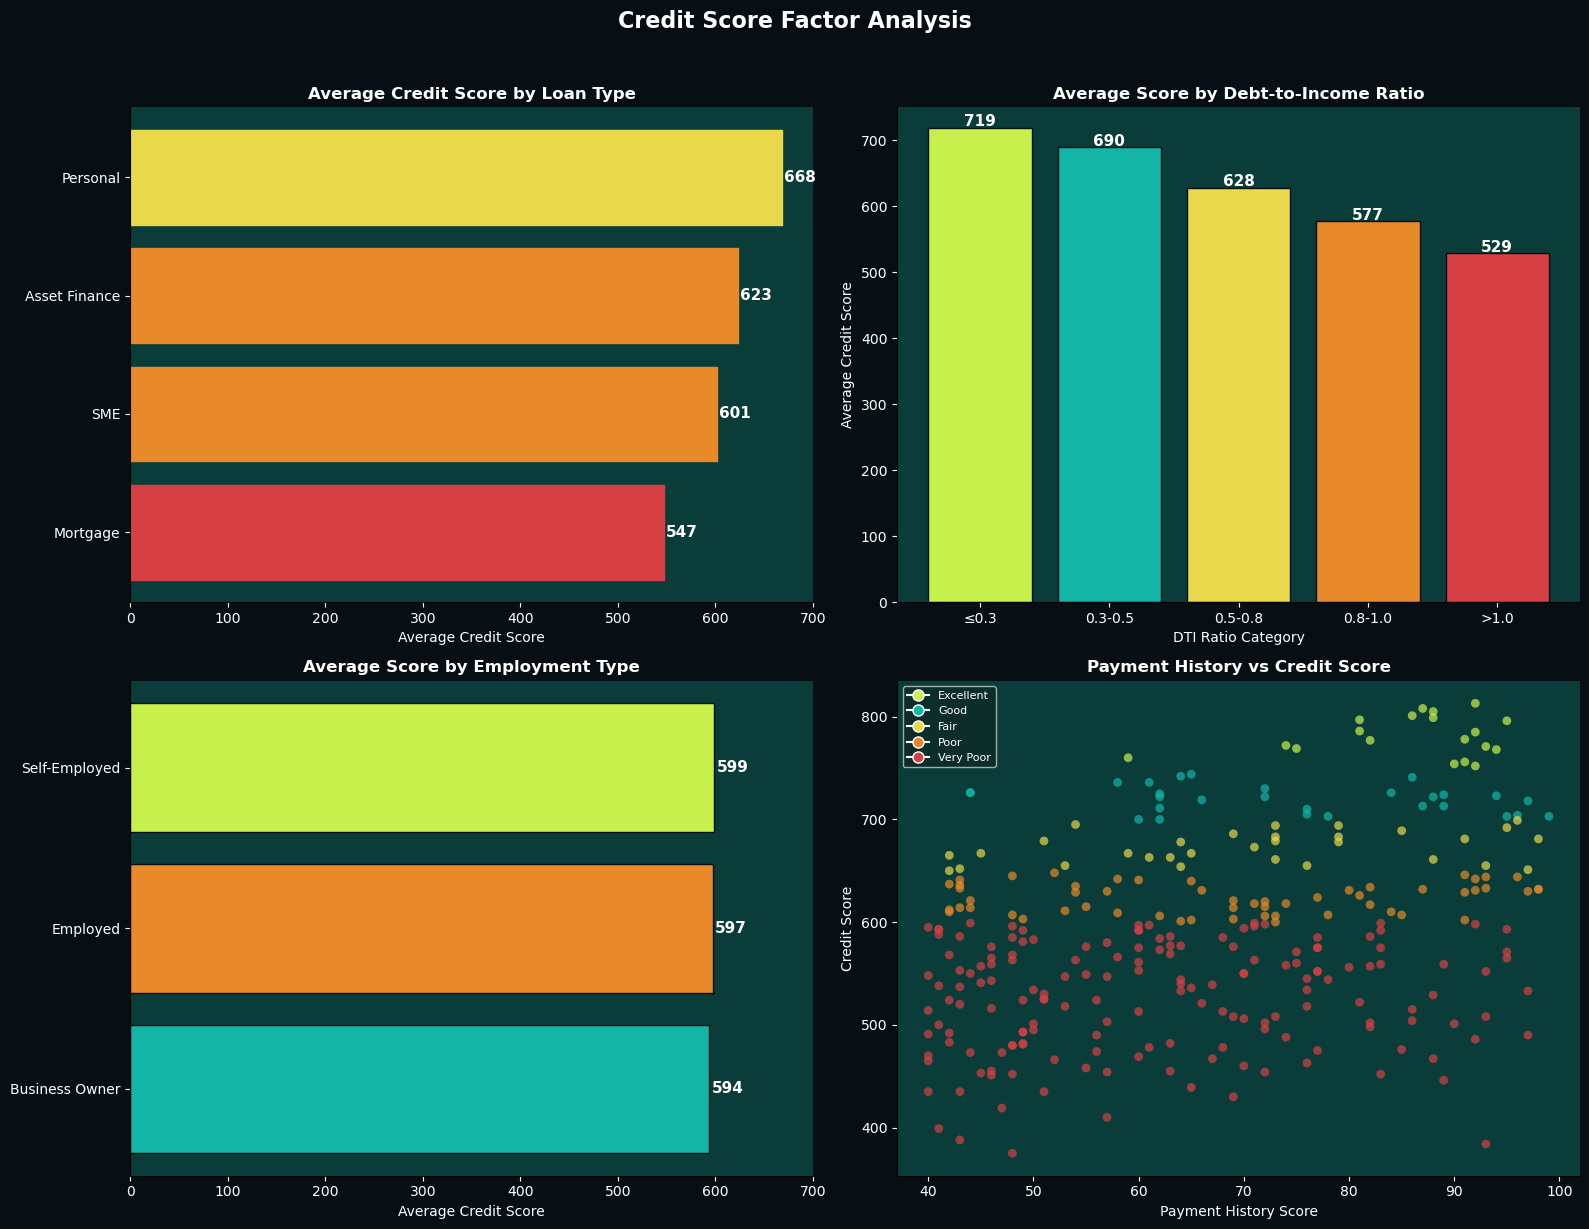

✅ Chart saved to outputs/charts/02_factor_analysis.png


In [10]:
# What drives high and low credit scores?

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Credit Score Factor Analysis',
             fontsize=16, fontweight='bold', color='white', y=1.02)

# ── Chart 1: Avg Score by Loan Type ──────────────
ax1 = axes[0, 0]
ax1.set_facecolor('#0A3D3A')

avg_by_loan = df.groupby('loan_type')['credit_score'].mean().sort_values()
bars = ax1.barh(avg_by_loan.index, avg_by_loan.values,
                color='#13B5A7', edgecolor='#080F14')

# Colour bars by score
for bar, val in zip(bars, avg_by_loan.values):
    if val < 600:
        bar.set_color('#D64045')
    elif val < 650:
        bar.set_color('#E8892A')
    elif val < 700:
        bar.set_color('#E8D84A')
    else:
        bar.set_color('#13B5A7')

    ax1.text(val + 2, bar.get_y() + bar.get_height()/2,
             f'{val:.0f}', va='center', color='white', fontsize=11,
             fontweight='bold')

ax1.set_title('Average Credit Score by Loan Type',
              fontsize=12, fontweight='bold', color='white')
ax1.set_xlabel('Average Credit Score', fontsize=10)
ax1.set_xlim(0, 700)
ax1.tick_params(colors='white')

# ── Chart 2: Score vs DTI Ratio ───────────────────
ax2 = axes[0, 1]
ax2.set_facecolor('#0A3D3A')

# Bin DTI into categories
dti_bins   = [0, 0.3, 0.5, 0.8, 1.0, 100]
dti_labels = ['≤0.3', '0.3-0.5', '0.5-0.8', '0.8-1.0', '>1.0']
df['dti_category'] = pd.cut(df['debt_to_income_ratio'],
                             bins=dti_bins, labels=dti_labels)

avg_by_dti = df.groupby('dti_category', observed=True)['credit_score'].mean()
colors_dti = ['#C8F04C', '#13B5A7', '#E8D84A', '#E8892A', '#D64045']

bars2 = ax2.bar(avg_by_dti.index, avg_by_dti.values,
                color=colors_dti, edgecolor='#080F14')

for bar, val in zip(bars2, avg_by_dti.values):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 2,
             f'{val:.0f}', ha='center', color='white',
             fontsize=11, fontweight='bold')

ax2.set_title('Average Score by Debt-to-Income Ratio',
              fontsize=12, fontweight='bold', color='white')
ax2.set_xlabel('DTI Ratio Category', fontsize=10)
ax2.set_ylabel('Average Credit Score', fontsize=10)
ax2.set_ylim(0, 750)
ax2.tick_params(colors='white')

# ── Chart 3: Score by Employment Type ────────────
ax3 = axes[1, 0]
ax3.set_facecolor('#0A3D3A')

avg_by_emp = df.groupby('employment_type')['credit_score'].mean().sort_values()
bars3 = ax3.barh(avg_by_emp.index, avg_by_emp.values,
                 color=['#13B5A7', '#E8892A', '#C8F04C'],
                 edgecolor='#080F14')

for bar, val in zip(bars3, avg_by_emp.values):
    ax3.text(val + 2, bar.get_y() + bar.get_height()/2,
             f'{val:.0f}', va='center', color='white',
             fontsize=11, fontweight='bold')

ax3.set_title('Average Score by Employment Type',
              fontsize=12, fontweight='bold', color='white')
ax3.set_xlabel('Average Credit Score', fontsize=10)
ax3.set_xlim(0, 700)
ax3.tick_params(colors='white')

# ── Chart 4: Payment History vs Score ────────────
ax4 = axes[1, 1]
ax4.set_facecolor('#0A3D3A')

# Sample 300 points for readability
sample = df.sample(300, random_state=42)
scatter_colors = sample['credit_rating'].map({
    'Excellent': '#C8F04C',
    'Good':      '#13B5A7',
    'Fair':      '#E8D84A',
    'Poor':      '#E8892A',
    'Very Poor': '#D64045',
})

ax4.scatter(sample['payment_history_score'],
            sample['credit_score'],
            c=scatter_colors, alpha=0.7, s=40, edgecolors='none')

ax4.set_title('Payment History vs Credit Score',
              fontsize=12, fontweight='bold', color='white')
ax4.set_xlabel('Payment History Score', fontsize=10)
ax4.set_ylabel('Credit Score', fontsize=10)
ax4.tick_params(colors='white')

# Legend for scatter
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#C8F04C',
           markersize=8, label='Excellent'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#13B5A7',
           markersize=8, label='Good'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#E8D84A',
           markersize=8, label='Fair'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#E8892A',
           markersize=8, label='Poor'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#D64045',
           markersize=8, label='Very Poor'),
]
ax4.legend(handles=legend_elements, loc='upper left',
           fontsize=8, facecolor='#0D2B28', labelcolor='white')

plt.tight_layout()
plt.savefig('outputs/charts/02_factor_analysis.png',
            dpi=150, bbox_inches='tight', facecolor='#080F14')
plt.show()
print("✅ Chart saved to outputs/charts/02_factor_analysis.png")

#### SECTION 8 — COLLATERAL & INCOME ANALYSIS

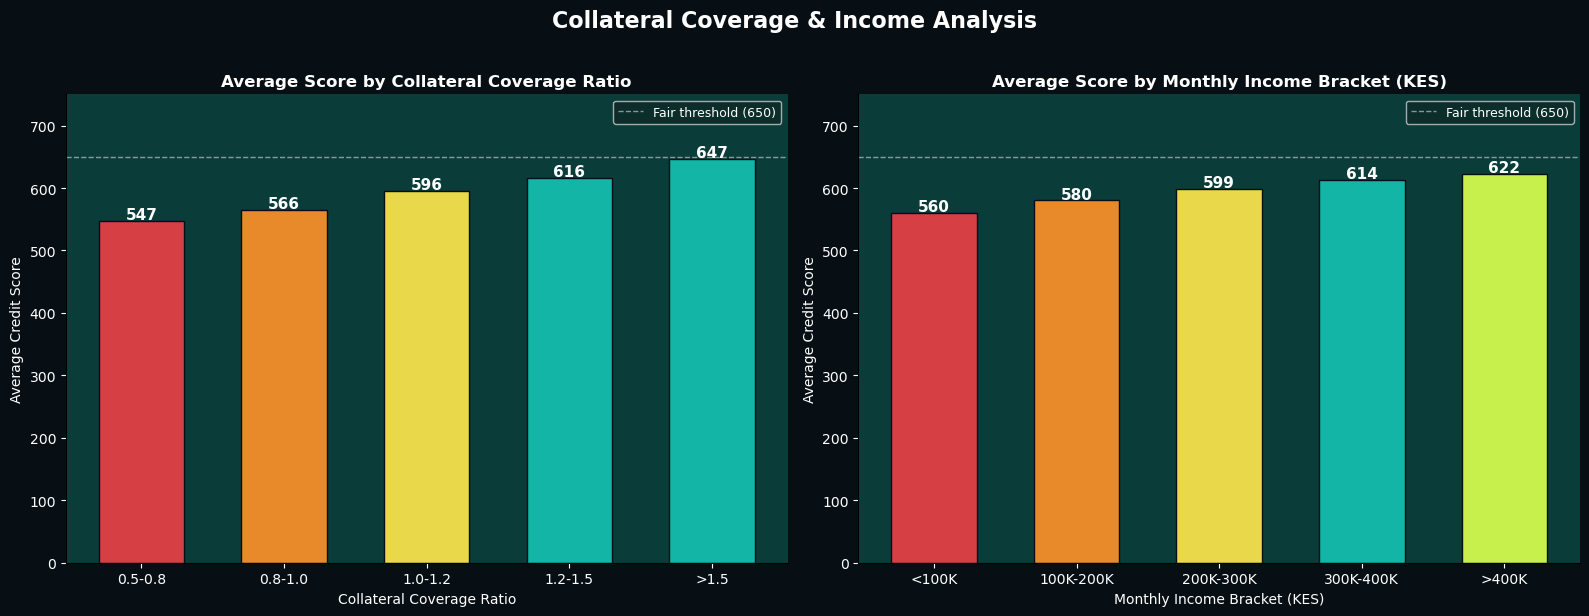

✅ Chart saved to outputs/charts/03_collateral_income_analysis.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Collateral Coverage & Income Analysis',
             fontsize=16, fontweight='bold', color='white', y=1.02)

# ── Chart 1: Score by Collateral Coverage ────────
ax1 = axes[0]
ax1.set_facecolor('#0A3D3A')

ccr_bins   = [0, 0.5, 0.8, 1.0, 1.2, 1.5, 10]
ccr_labels = ['<0.5', '0.5-0.8', '0.8-1.0',
              '1.0-1.2', '1.2-1.5', '>1.5']
df['ccr_category'] = pd.cut(df['collateral_coverage_ratio'],
                             bins=ccr_bins, labels=ccr_labels)

avg_by_ccr = df.groupby('ccr_category',
                         observed=True)['credit_score'].mean()
colors_ccr = ['#D64045', '#E8892A', '#E8D84A',
              '#13B5A7', '#13B5A7', '#C8F04C']

bars = ax1.bar(avg_by_ccr.index, avg_by_ccr.values,
               color=colors_ccr, edgecolor='#080F14', width=0.6)

for bar, val in zip(bars, avg_by_ccr.values):
    ax1.text(bar.get_x() + bar.get_width()/2, val + 3,
             f'{val:.0f}', ha='center', color='white',
             fontsize=11, fontweight='bold')

# Reference line at 650 (Fair threshold)
ax1.axhline(y=650, color='white', linestyle='--',
            linewidth=1, alpha=0.5, label='Fair threshold (650)')
ax1.legend(fontsize=9, facecolor='#0D2B28', labelcolor='white')

ax1.set_title('Average Score by Collateral Coverage Ratio',
              fontsize=12, fontweight='bold', color='white')
ax1.set_xlabel('Collateral Coverage Ratio', fontsize=10)
ax1.set_ylabel('Average Credit Score', fontsize=10)
ax1.set_ylim(0, 750)
ax1.tick_params(colors='white')

# ── Chart 2: Score by Income Bracket ─────────────
ax2 = axes[1]
ax2.set_facecolor('#0A3D3A')

# Create income brackets
income_bins   = [0, 100000, 200000, 300000, 400000, 999999]
income_labels = ['<100K', '100K-200K', '200K-300K',
                 '300K-400K', '>400K']
df['income_bracket'] = pd.cut(df['monthly_income'],
                               bins=income_bins,
                               labels=income_labels)

avg_by_income = df.groupby('income_bracket',
                            observed=True)['credit_score'].mean()
colors_income = ['#D64045', '#E8892A', '#E8D84A',
                 '#13B5A7', '#C8F04C']

bars2 = ax2.bar(avg_by_income.index, avg_by_income.values,
                color=colors_income, edgecolor='#080F14', width=0.6)

for bar, val in zip(bars2, avg_by_income.values):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 3,
             f'{val:.0f}', ha='center', color='white',
             fontsize=11, fontweight='bold')

ax2.axhline(y=650, color='white', linestyle='--',
            linewidth=1, alpha=0.5, label='Fair threshold (650)')
ax2.legend(fontsize=9, facecolor='#0D2B28', labelcolor='white')

ax2.set_title('Average Score by Monthly Income Bracket (KES)',
              fontsize=12, fontweight='bold', color='white')
ax2.set_xlabel('Monthly Income Bracket (KES)', fontsize=10)
ax2.set_ylabel('Average Credit Score', fontsize=10)
ax2.set_ylim(0, 750)
ax2.tick_params(colors='white')

plt.tight_layout()
plt.savefig('outputs/charts/03_collateral_income_analysis.png',
            dpi=150, bbox_inches='tight', facecolor='#080F14')
plt.show()
print("✅ Chart saved to outputs/charts/03_collateral_income_analysis.png")

#### Section 9 — Loan Decision Summary Chart

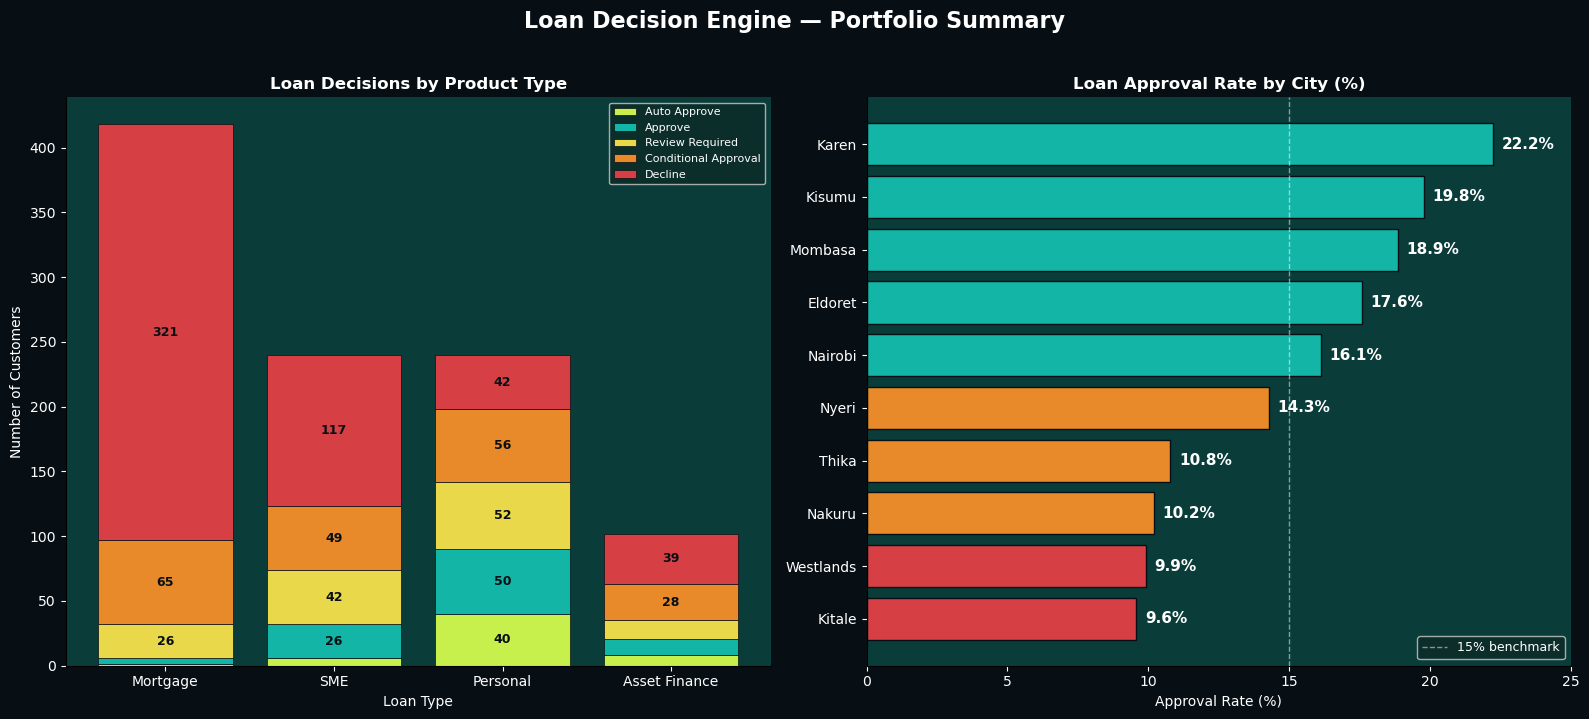

✅ Chart saved to outputs/charts/04_loan_decisions.png


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Loan Decision Engine — Portfolio Summary',
             fontsize=16, fontweight='bold', color='white', y=1.02)

# ── Chart 1: Decision by Loan Type (Stacked Bar) ─
ax1 = axes[0]
ax1.set_facecolor('#0A3D3A')

decision_order = ['Auto Approve', 'Approve', 'Review Required',
                  'Conditional Approval', 'Decline']
colors_dec = ['#C8F04C', '#13B5A7', '#E8D84A', '#E8892A', '#D64045']

pivot = df.groupby(['loan_type', 'loan_decision']).size().unstack(fill_value=0)
pivot = pivot.reindex(columns=decision_order, fill_value=0)
loan_type_order = ['Mortgage', 'SME', 'Personal', 'Asset Finance']
pivot = pivot.reindex(loan_type_order, fill_value=0)

bottom = np.zeros(len(pivot))
for col, color in zip(decision_order, colors_dec):
    values = pivot[col].values
    bars = ax1.bar(pivot.index, values, bottom=bottom,
                   color=color, edgecolor='#080F14',
                   linewidth=0.5, label=col)
    # Add labels for large segments
    for bar, val, bot in zip(bars, values, bottom):
        if val > 15:
            ax1.text(bar.get_x() + bar.get_width()/2,
                     bot + val/2, str(val),
                     ha='center', va='center',
                     color='#080F14', fontsize=9, fontweight='bold')
    bottom += values

ax1.set_title('Loan Decisions by Product Type',
              fontsize=12, fontweight='bold', color='white')
ax1.set_xlabel('Loan Type', fontsize=10)
ax1.set_ylabel('Number of Customers', fontsize=10)
ax1.tick_params(colors='white')
ax1.legend(loc='upper right', fontsize=8,
           facecolor='#0D2B28', labelcolor='white')

# ── Chart 2: City-level Approval Rate ────────────
ax2 = axes[1]
ax2.set_facecolor('#0A3D3A')

# Calculate approval rate per city
city_decisions = df.groupby('city')['loan_decision'].apply(
    lambda x: (x.isin(['Auto Approve', 'Approve'])).sum() / len(x) * 100
).sort_values(ascending=True)

colors_city = ['#D64045' if v < 10 else
               '#E8892A' if v < 15 else
               '#13B5A7' for v in city_decisions.values]

bars = ax2.barh(city_decisions.index, city_decisions.values,
                color=colors_city, edgecolor='#080F14')

for bar, val in zip(bars, city_decisions.values):
    ax2.text(val + 0.3, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}%', va='center', color='white',
             fontsize=11, fontweight='bold')

ax2.axvline(x=15, color='white', linestyle='--',
            linewidth=1, alpha=0.5, label='15% benchmark')
ax2.legend(fontsize=9, facecolor='#0D2B28', labelcolor='white')

ax2.set_title('Loan Approval Rate by City (%)',
              fontsize=12, fontweight='bold', color='white')
ax2.set_xlabel('Approval Rate (%)', fontsize=10)
ax2.set_xlim(0, 25)
ax2.tick_params(colors='white')

plt.tight_layout()
plt.savefig('outputs/charts/04_loan_decisions.png',
            dpi=150, bbox_inches='tight', facecolor='#080F14')
plt.show()
print("✅ Chart saved to outputs/charts/04_loan_decisions.png")

#### Section 10 — Key Findings & Export to Excel

In [14]:
print("=" * 60)
print("   CUSTOMER CREDIT SCORING MODEL — KEY FINDINGS")
print("=" * 60)

total = len(df)
approved = df['loan_decision'].isin(['Auto Approve', 'Approve']).sum()
declined = (df['loan_decision'] == 'Decline').sum()
review   = df['loan_decision'].isin(
    ['Review Required', 'Conditional Approval']).sum()

print(f"""
📊 PORTFOLIO OVERVIEW
{'─'*40}
Total Applications    : {total:,}
Approved              : {approved:,} ({approved/total*100:.1f}%)
Under Review          : {review:,} ({review/total*100:.1f}%)
Declined              : {declined:,} ({declined/total*100:.1f}%)

📈 SCORE STATISTICS
{'─'*40}
Average Credit Score  : {df['credit_score'].mean():.0f}
Highest Score         : {df['credit_score'].max()}
Lowest Score          : {df['credit_score'].min()}
Customers Above 700   : {(df['credit_score'] >= 700).sum()} ({(df['credit_score'] >= 700).sum()/total*100:.1f}%)

⚠️  RISK INDICATORS
{'─'*40}
High DTI (>0.5)       : {(df['debt_to_income_ratio'] > 0.5).sum():,} customers ({(df['debt_to_income_ratio'] > 0.5).sum()/total*100:.1f}%)
Under-Collateralised  : {(df['collateral_coverage_ratio'] < 1.0).sum():,} customers ({(df['collateral_coverage_ratio'] < 1.0).sum()/total*100:.1f}%)
Previous Defaulters   : {(df['previous_defaults'] > 0).sum():,} customers ({(df['previous_defaults'] > 0).sum()/total*100:.1f}%)

🏆 TOP PERFORMING SEGMENTS
{'─'*40}
Best Loan Type        : Personal (avg score {df[df['loan_type']=='Personal']['credit_score'].mean():.0f})
Best City             : {df.groupby('city')['credit_score'].mean().idxmax()} (avg score {df.groupby('city')['credit_score'].mean().max():.0f})
Best Income Bracket   : >400K KES/month (avg score {df[df['income_bracket']=='>400K']['credit_score'].mean():.0f})

🔴 HIGHEST RISK SEGMENTS
{'─'*40}
Riskiest Loan Type    : Mortgage (avg score {df[df['loan_type']=='Mortgage']['credit_score'].mean():.0f})
Riskiest City         : {df.groupby('city')['credit_score'].mean().idxmin()} (avg score {df.groupby('city')['credit_score'].mean().min():.0f})
""")

# ── Export to Excel ───────────────────────────────
print("💾 Exporting results to Excel...")

with pd.ExcelWriter('outputs/credit_scoring_results.xlsx',
                    engine='openpyxl') as writer:

    # Sheet 1 — Full scored dataset
    df.to_excel(writer, sheet_name='Full Dataset', index=False)

    # Sheet 2 — Approved customers
    approved_df = df[df['loan_decision'].isin(
        ['Auto Approve', 'Approve'])].copy()
    approved_df.to_excel(writer, sheet_name='Approved', index=False)

    # Sheet 3 — Declined customers
    declined_df = df[df['loan_decision'] == 'Decline'].copy()
    declined_df.to_excel(writer, sheet_name='Declined', index=False)

    # Sheet 4 — High Risk customers
    high_risk = df[
        (df['debt_to_income_ratio'] > 0.5) |
        (df['collateral_coverage_ratio'] < 1.0) |
        (df['previous_defaults'] > 0)
    ].copy()
    high_risk.to_excel(writer, sheet_name='High Risk', index=False)

    # Sheet 5 — Summary statistics
    summary = pd.DataFrame({
        'Metric': [
            'Total Applications', 'Approved', 'Under Review',
            'Declined', 'Average Credit Score', 'Highest Score',
            'Lowest Score', 'High DTI Customers',
            'Under-Collateralised', 'Previous Defaulters'
        ],
        'Value': [
            total, approved, review, declined,
            round(df['credit_score'].mean()),
            df['credit_score'].max(),
            df['credit_score'].min(),
            (df['debt_to_income_ratio'] > 0.5).sum(),
            (df['collateral_coverage_ratio'] < 1.0).sum(),
            (df['previous_defaults'] > 0).sum()
        ]
    })
    summary.to_excel(writer, sheet_name='Summary', index=False)

print("✅ Excel file saved to outputs/credit_scoring_results.xlsx")
print("\n📁 Charts saved:")
print("   outputs/charts/01_score_distribution.png")
print("   outputs/charts/02_factor_analysis.png")
print("   outputs/charts/03_collateral_income_analysis.png")
print("   outputs/charts/04_loan_decisions.png")
print("\n🎉 PROJECT COMPLETE!")
print("=" * 60)

   CUSTOMER CREDIT SCORING MODEL — KEY FINDINGS

📊 PORTFOLIO OVERVIEW
────────────────────────────────────────
Total Applications    : 1,000
Approved              : 149 (14.9%)
Under Review          : 332 (33.2%)
Declined              : 519 (51.9%)

📈 SCORE STATISTICS
────────────────────────────────────────
Average Credit Score  : 597
Highest Score         : 820
Lowest Score          : 375
Customers Above 700   : 149 (14.9%)

⚠️  RISK INDICATORS
────────────────────────────────────────
High DTI (>0.5)       : 769 customers (76.9%)
Under-Collateralised  : 383 customers (38.3%)
Previous Defaulters   : 338 customers (33.8%)

🏆 TOP PERFORMING SEGMENTS
────────────────────────────────────────
Best Loan Type        : Personal (avg score 668)
Best City             : Karen (avg score 609)
Best Income Bracket   : >400K KES/month (avg score 622)

🔴 HIGHEST RISK SEGMENTS
────────────────────────────────────────
Riskiest Loan Type    : Mortgage (avg score 547)
Riskiest City         : Thika (avg s